In [33]:
import pandas as pd
import pyterrier as pt
import glob
import os
import tqdm
import seaborn as sns
import matplotlib.pyplot as plt

In [34]:
DATA_DIR = '../data'
RUN_DIR = os.path.join(DATA_DIR, 'runs')

In [35]:
dl20_pattern = 'dl-20-*'
dl19_pattern = 'dl-19-*'

In [36]:
qrel_paths = [d for d in os.listdir(DATA_DIR) if 'trec-dl' in d]

In [37]:
def parse_line(line):
    # 23849 q0 1020327 1
    line = line.strip()
    parts = line.split(' ')
    return {
        'query_id': parts[0],
        'doc_id': parts[2],
        'relevance': int(parts[3])
    }

def read_all_qrels(path):
    out = []
    for f in os.listdir(path):
        with open(os.path.join(path, f), 'r') as qrel_file:
            lines = map(parse_line, qrel_file.readlines())
        system = f.split('.')[0]
        frame = pd.DataFrame(lines)
        frame['system'] = system
        out.append(frame)
    return pd.concat(out)

In [38]:
from ir_measures import *
from ir_measures import evaluator
from functools import partial
rel = 2
metrics = [
        AP(rel=rel),
        NDCG(cutoff=10),
        R(rel=rel) @ 100,
        P(rel=rel, cutoff=10),
        RR(rel=rel),
        RR(rel=rel, cutoff=10),
    ]
constructor = partial(evaluator, measures=metrics)

def evaluate_system(run, qrels):
    output = []
    for item in constructor(qrels=qrels).iter_calc(run.rename(columns={'qid' : 'query_id', 'docno' : 'doc_id'})):
        output.append({
            'query_id' : item.query_id,
            'measure' : str(item.measure),
            'value' : item.value
        })
    return pd.DataFrame.from_records(output)

In [39]:
qrels = {}
for path in qrel_paths:
    if '19' in path:
        type = '19'
    else:
        type = '20'
    qrels[type] = read_all_qrels(os.path.join(DATA_DIR, path, 'qrels'))

In [40]:
dl19_runs = glob.glob(os.path.join(RUN_DIR, "**",dl19_pattern))
dl20_runs = glob.glob(os.path.join(RUN_DIR, "**",dl20_pattern))

In [41]:
run_files = {}
for type in ['19', '20']:
    run_files[type] = glob.glob(os.path.join(RUN_DIR, "**", f'dl-{type}-*'))

In [42]:
runs = {}
for type, files in run_files.items():
    runs[type] = [pt.io.read_results(f) for f in files]
    for run, f in zip(runs[type], files):
        run['system'] = f.split('/')[-1].split('.')[1]

In [43]:
eval_result = {}
for group, subqrels in qrels.items():
    group_runs = runs[group]
    tmp = []
    for system, system_qrels in subqrels.groupby('system'):
        for run in tqdm.tqdm(group_runs):
            results = evaluate_system(run, system_qrels)
            results['system'] = run['system'].iloc[0]
            results['source'] = system
            tmp.append(results)
    eval_result[group] = pd.concat(tmp)

100%|██████████| 37/37 [00:08<00:00,  4.21it/s]


In [44]:
eval_result['19'].columns

Index(['query_id', 'measure', 'value', 'system', 'source'], dtype='object')

In [59]:
grouped_results = {}
for group, results in eval_result.items():
    grouped_results[group] = results.groupby(['system', 'source', 'measure'])['value'].agg('mean').reset_index()

In [60]:
grouped_results['19']

,system,source,measure,value
0,ICT-BERT2,AnthropicLLM-claude-3-5-haiku-20241022-umbrell...,AP(rel=2),0.154848
1,ICT-BERT2,AnthropicLLM-claude-3-5-haiku-20241022-umbrell...,P(rel=2)@10,0.846512
2,ICT-BERT2,AnthropicLLM-claude-3-5-haiku-20241022-umbrell...,R(rel=2)@100,0.168892
3,ICT-BERT2,AnthropicLLM-claude-3-5-haiku-20241022-umbrell...,RR(rel=2),1.000000
4,ICT-BERT2,AnthropicLLM-claude-3-5-haiku-20241022-umbrell...,RR(rel=2)@10,1.000000
...,...,...,...,...
1993,test1,trec,P(rel=2)@10,0.637209
1994,test1,trec,R(rel=2)@100,0.582126
1995,test1,trec,RR(rel=2),0.870155
1996,test1,trec,RR(rel=2)@10,0.870155


In [45]:
def get_system_order(df, metric_name, aggregation='mean'):
    # Filter by the specified metric
    df_metric = df[df['measure'] == metric_name]
    
    # Aggregate values over all queries for each system and source
    aggregated = df_metric.groupby(['source', 'system'])['value'].agg(aggregation).reset_index()
    
    # Sort systems within each source by aggregated value (descending)
    ordered = aggregated.sort_values(['source', 'value'], ascending=[True, False])
    
    # Group by source and extract the ordered system list
    system_order = ordered.groupby('source')['system'].apply(list).to_dict()
    
    return system_order

In [54]:
import pandas as pd

def get_system_order(df, metric_name, aggregation='mean'):
    # Filter by the specified metric
    df_metric = df[df['measure'] == metric_name]
    
    # Aggregate values over all queries for each system and source
    aggregated = df_metric.groupby(['source', 'system'])['value'].agg(aggregation).reset_index()
    
    # Sort systems within each source by aggregated value (descending)
    ordered = aggregated.sort_values(['source', 'value'], ascending=[True, False])
    
    # Group by source and extract the ordered system list
    system_order = ordered.groupby('source')['system'].apply(list).to_dict()
    
    return system_order


def calculate_avg_rank_change(df, reference_lists, aggregation='mean'):
    # Get the reference order    
    # Get all unique metrics
    unique_metrics = df['measure'].unique()
    
    rank_changes = {}  # To store average rank changes for each metric
    unique_systems = df['system'].unique().tolist()
    for metric in unique_metrics:
        reference_list = reference_lists[metric]
        # Get the system order for the current metric
        system_order = get_system_order(df, metric, aggregation)

        deltas = {s : [] for s in unique_systems}

        for _, ordered_systems in system_order.items():
    
            for system in unique_systems:
                ref_rank = reference_list.index(system)
                current_rank = ordered_systems.index(system)
                deltas[system].append(ref_rank - current_rank)
                
        
        rank_changes[metric] = {s : sum(deltas[s]) / len(deltas[s]) for s in unique_systems}
    
    return rank_changes

In [55]:
changes = {}
for group, df in eval_result.items():
    reference_lists = {}
    original_df = df[df.source=='trec']
    all_df = df[df.source!='trec']
    for metric in df['measure'].unique():
        reference_lists[metric] = get_system_order(original_df, metric, 'mean')['trec']
    rank_changes = calculate_avg_rank_change(all_df, reference_lists)
    changes[group] = rank_changes

In [56]:
changes.keys()

dict_keys(['20', '19'])

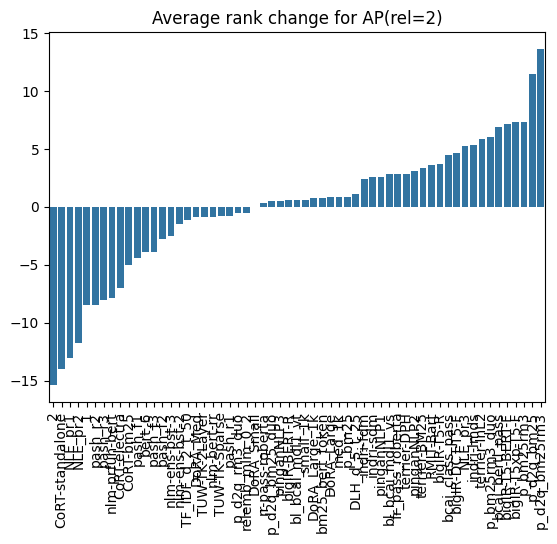

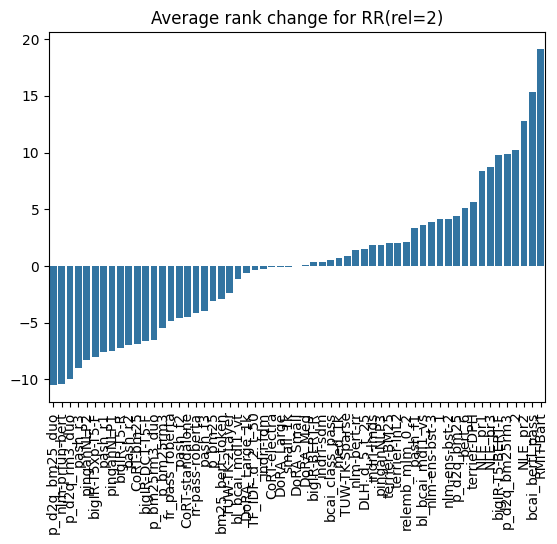

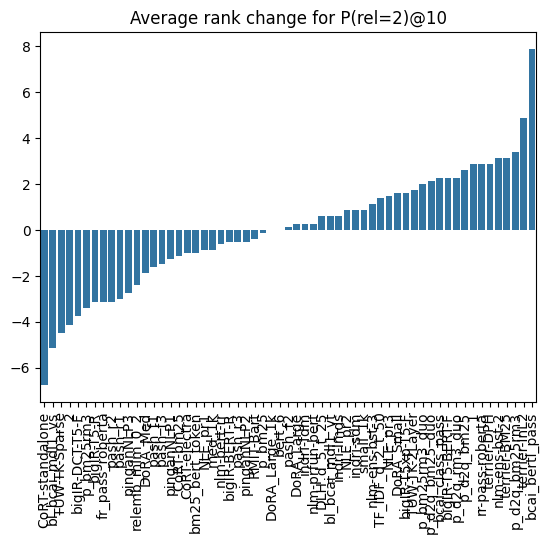

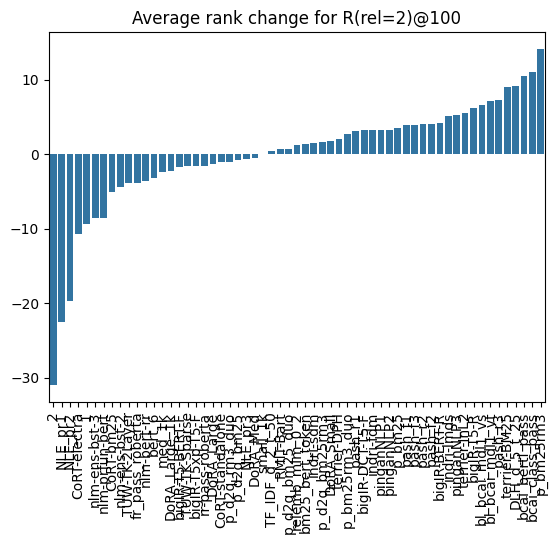

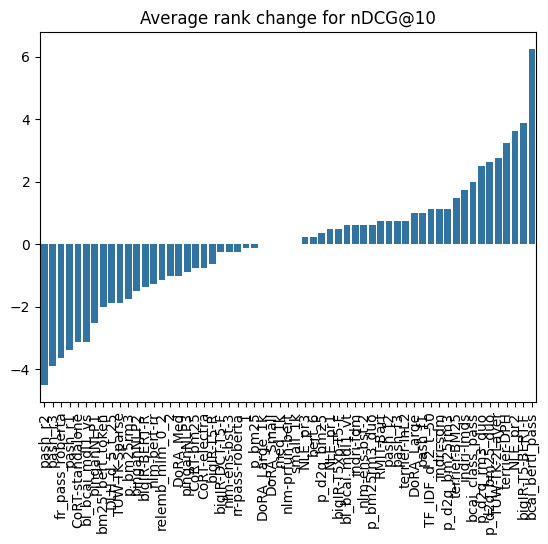

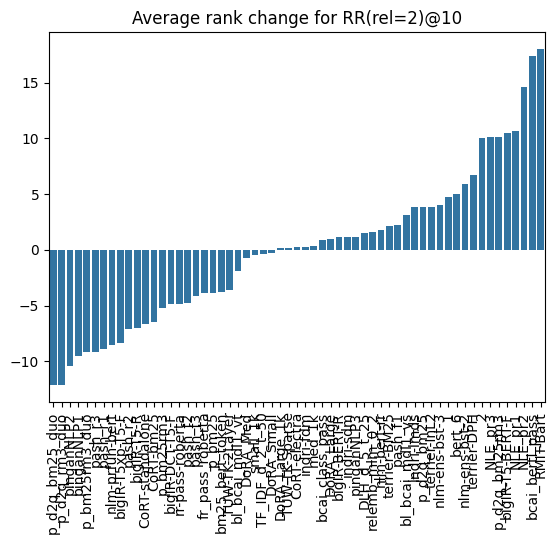

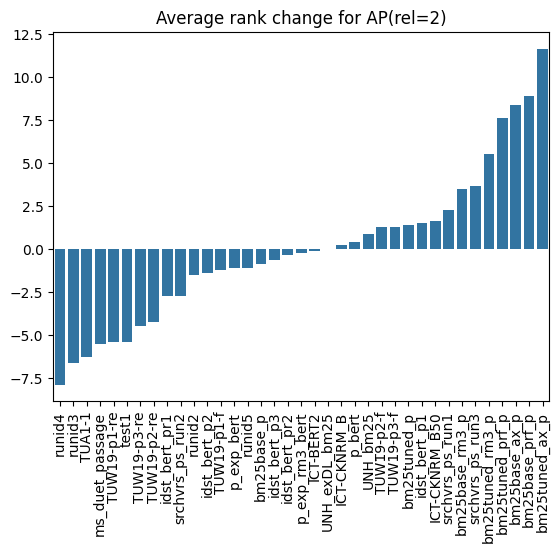

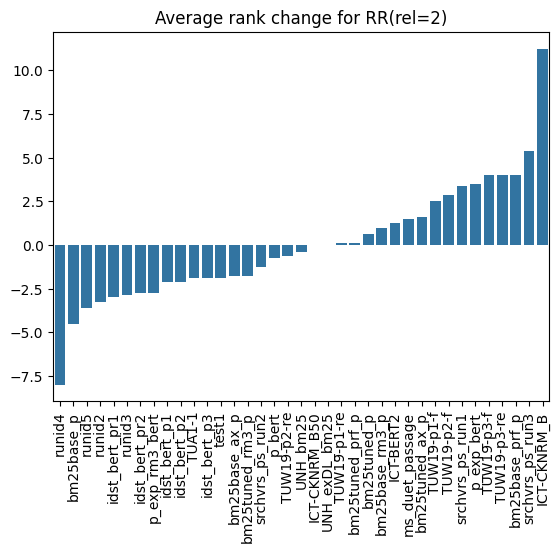

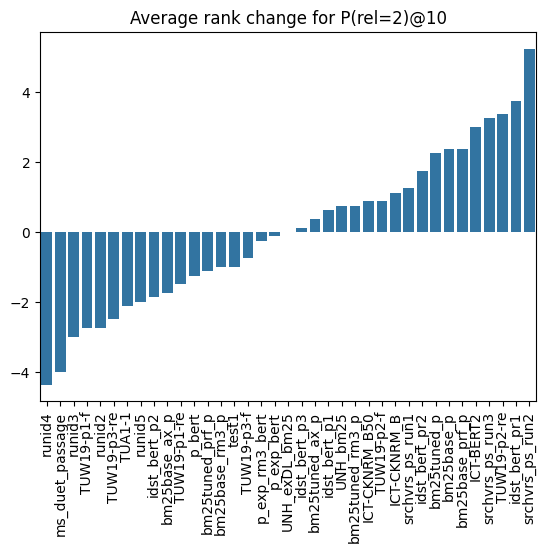

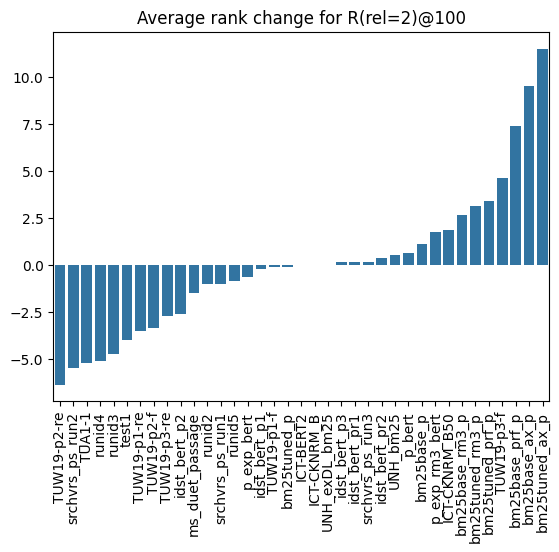

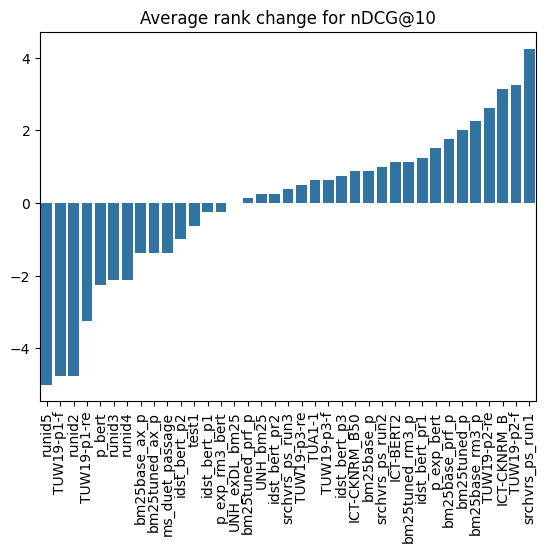

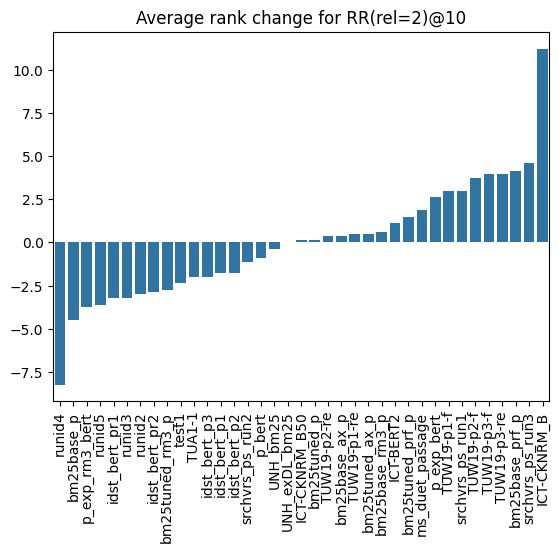

In [58]:
def plot_system_changes(change):
    for metric, changes in change.items():
        systems = list(changes.keys())
        values = list(changes.values())
        # order by value
        systems = [x for _, x in sorted(zip(values, systems))]
        values = sorted(values)
        sns.barplot(x=systems, y=values)
        plt.xticks(rotation=90)
        plt.title(f'Average rank change for {metric}')
        plt.show()

for key, change in changes.items():
    plot_system_changes(change)

In [64]:
import pandas as pd
from scipy.stats import kendalltau
import seaborn as sns
import matplotlib.pyplot as plt

def get_system_order(df, metric_name, aggregation='mean'):
    # Filter by the specified metric
    df_metric = df[df['measure'] == metric_name]
    
    # Aggregate values over all queries for each system and source
    aggregated = df_metric.groupby(['source', 'system'])['value'].agg(aggregation).reset_index()
    
    # Sort systems within each source by aggregated value (descending)
    ordered = aggregated.sort_values(['source', 'value'], ascending=[True, False])
    
    # Group by source and extract the ordered system list
    system_order = ordered.groupby('source')['system'].apply(list).to_dict()
    
    return system_order

def calculate_kendalls_tau_heatmap(df):
    # Get all unique metrics and sources
    unique_metrics = df['measure'].unique()
    unique_sources = df['source'].unique()
    
    for metric in unique_metrics:
        # Get the system order for the current metric
        system_order = get_system_order(df, metric)
        
        # Create an empty DataFrame to store Kendall's Tau values
        tau_matrix = pd.DataFrame(index=unique_sources, columns=unique_sources)
        
        # Calculate Kendall's Tau for each pair of sources
        for source1 in unique_sources:
            for source2 in unique_sources:
                if source1 == source2:
                    tau_matrix.loc[source1, source2] = 1.0  # Tau with itself is 1
                else:
                    # Get the system orders for the two sources
                    order1 = system_order.get(source1, [])
                    order2 = system_order.get(source2, [])
                    
                    # Only calculate Kendall's Tau if both sources have systems
                    if order1 and order2:
                        # Ensure both orders have the same systems in the same order
                        common_systems = [s for s in order1 if s in order2]
                        order1 = [s for s in order1 if s in common_systems]
                        order2 = [s for s in order2 if s in common_systems]
                        
                        # Calculate Kendall's Tau
                        tau, _ = kendalltau(order1, order2)
                        tau_matrix.loc[source1, source2] = tau
                    else:
                        tau_matrix.loc[source1, source2] = None  # Handle missing data
        
        # Convert to float for heatmap
        tau_matrix = tau_matrix.astype(float)
        
        # Plot the heatmap
        plt.figure(figsize=(8, 6))
        sns.heatmap(
            tau_matrix,
            annot=True,
            cmap="coolwarm",
            cbar=True,
            vmin=-1,
            vmax=1,
            center=0,
            xticklabels=unique_sources,
            yticklabels=unique_sources,
        )
        plt.title(f"Kendall's Tau Heatmap for Metric: {metric}")
        plt.xlabel("Source")
        plt.ylabel("Source")
        plt.show()

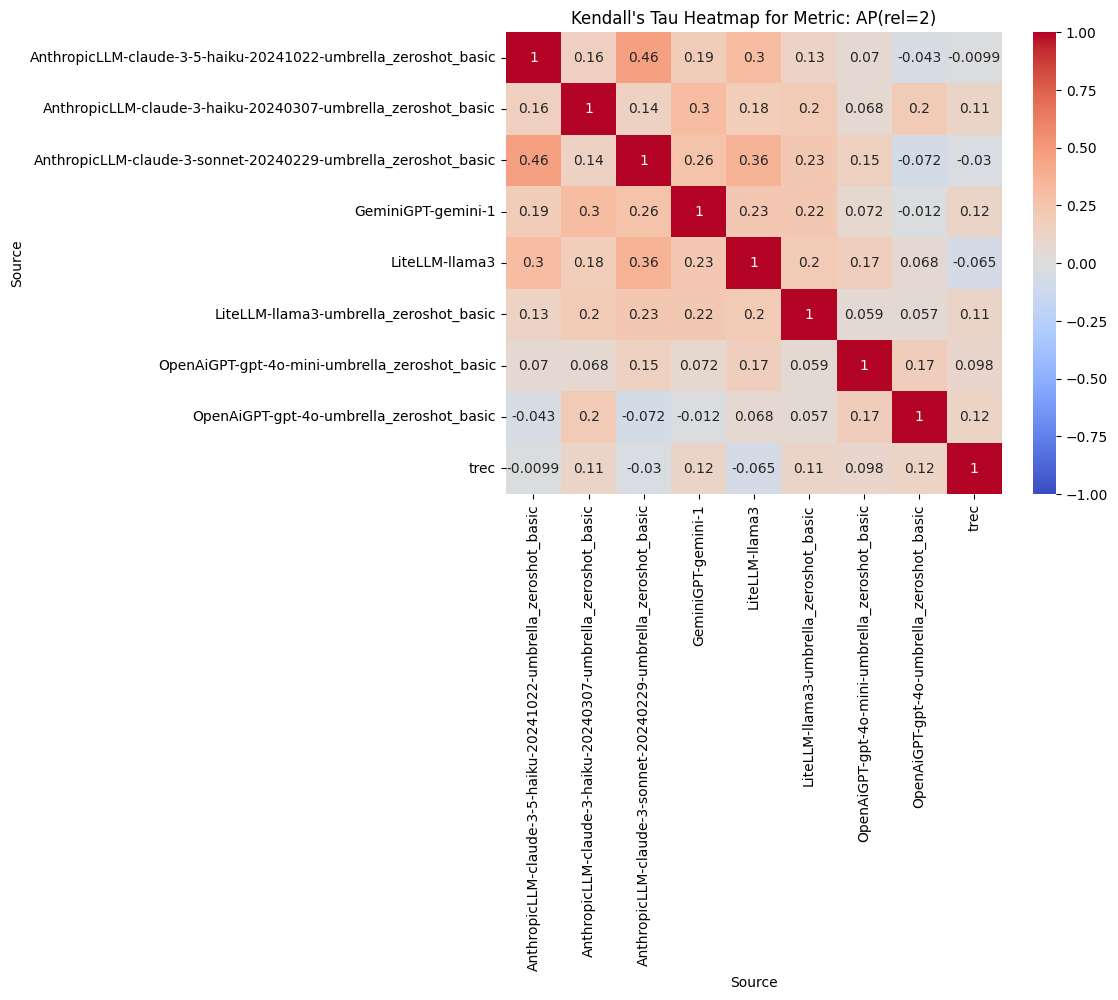

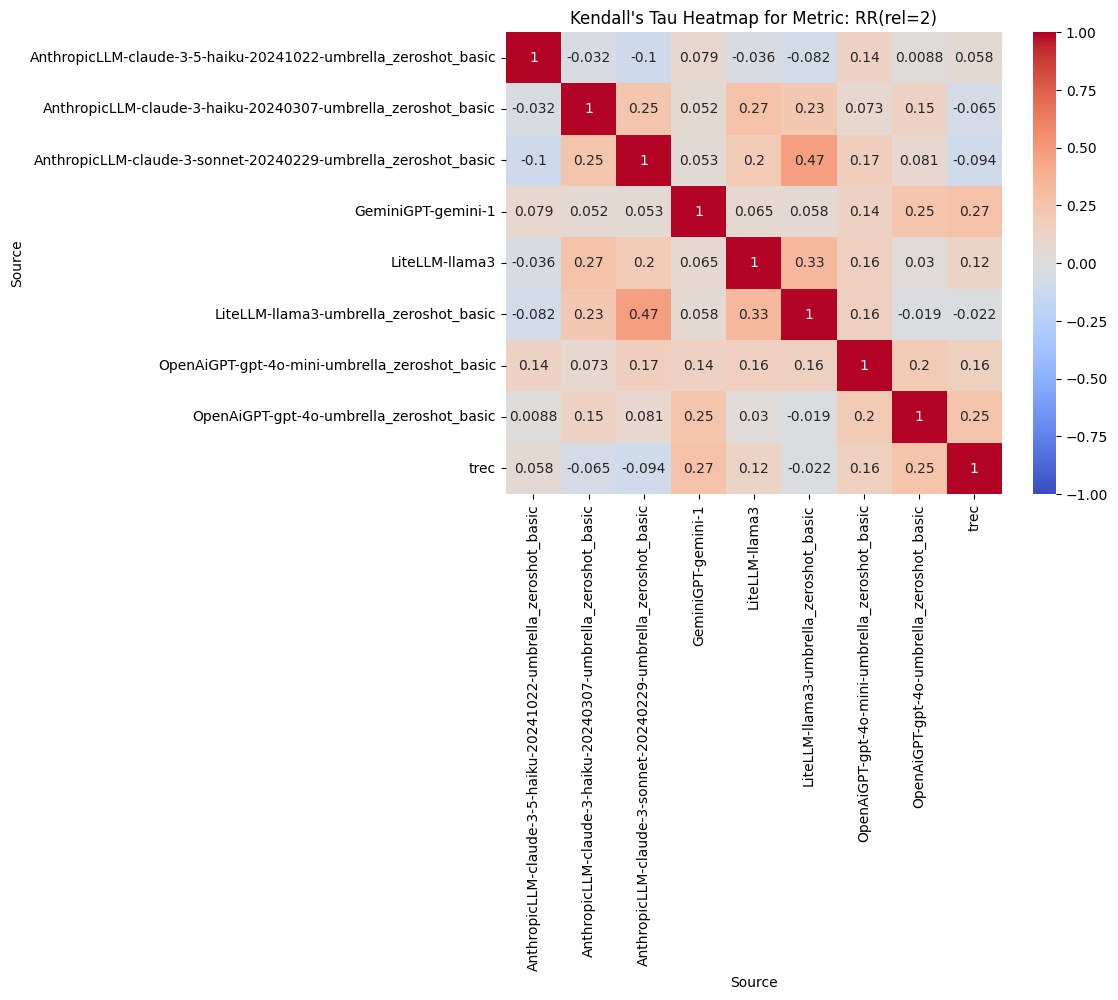

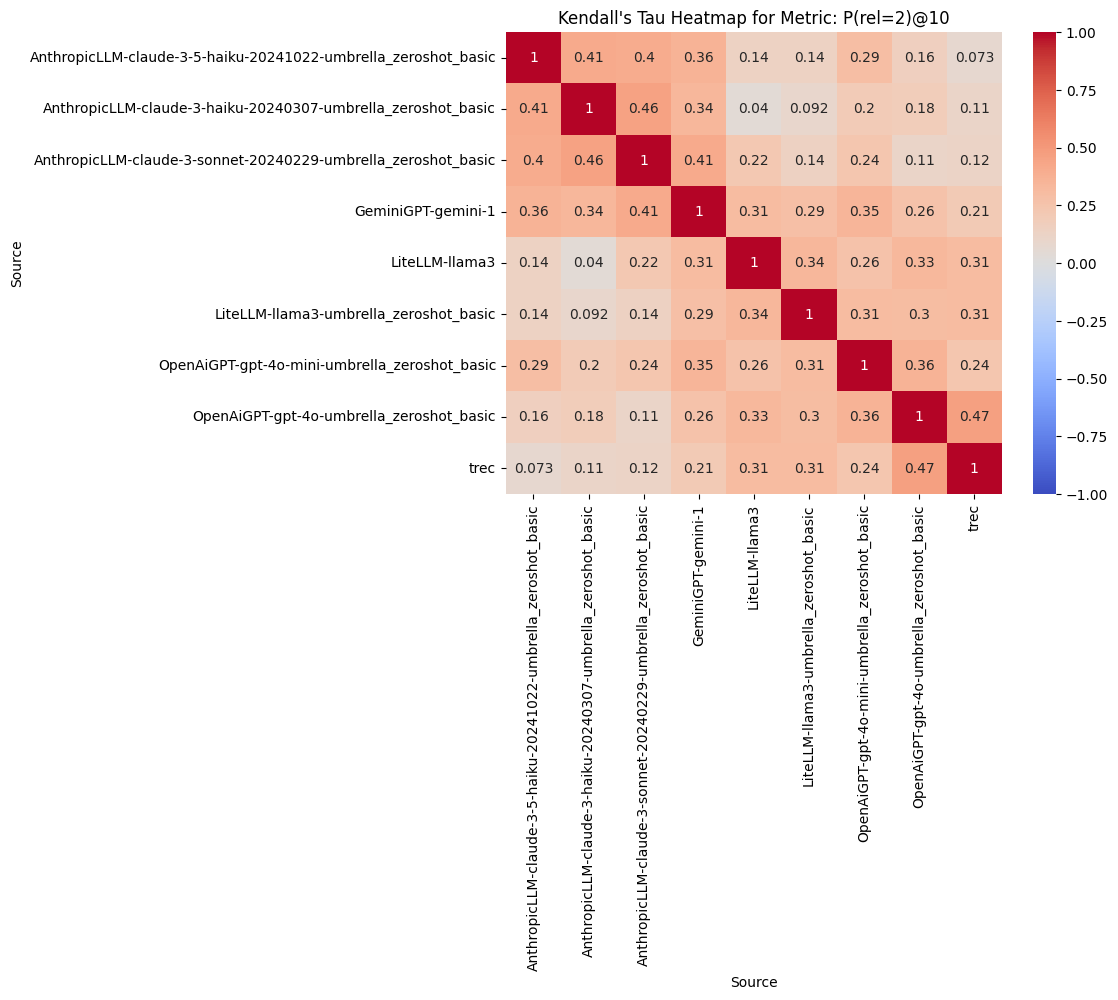

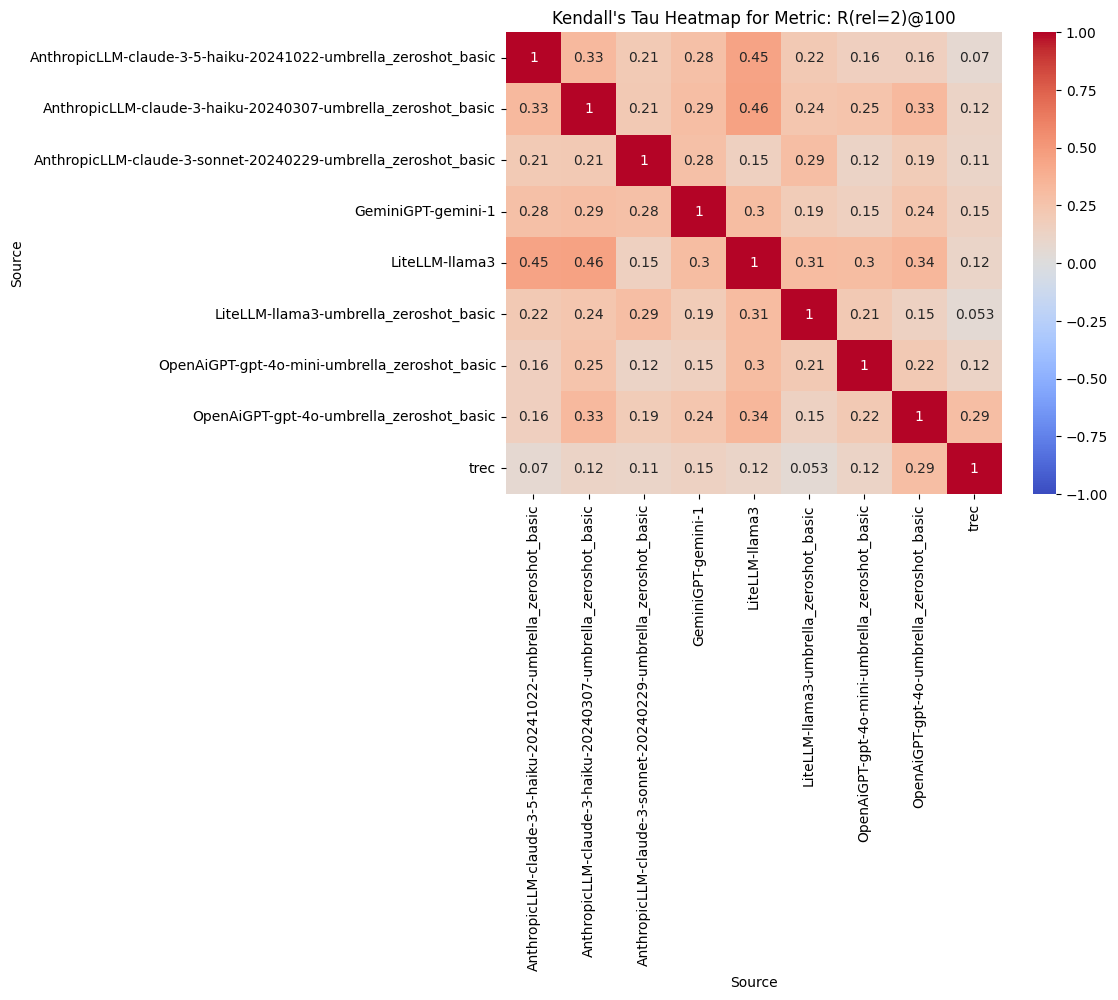

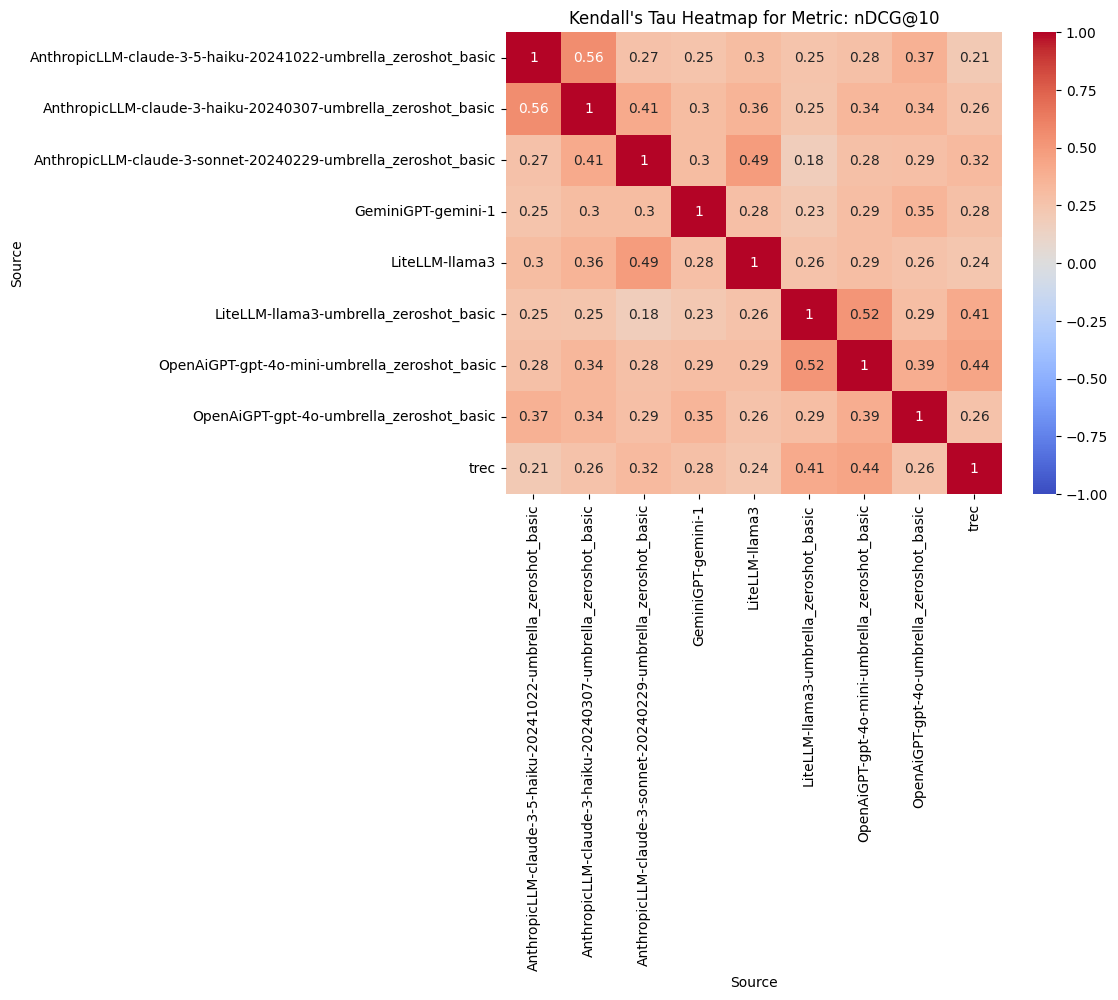

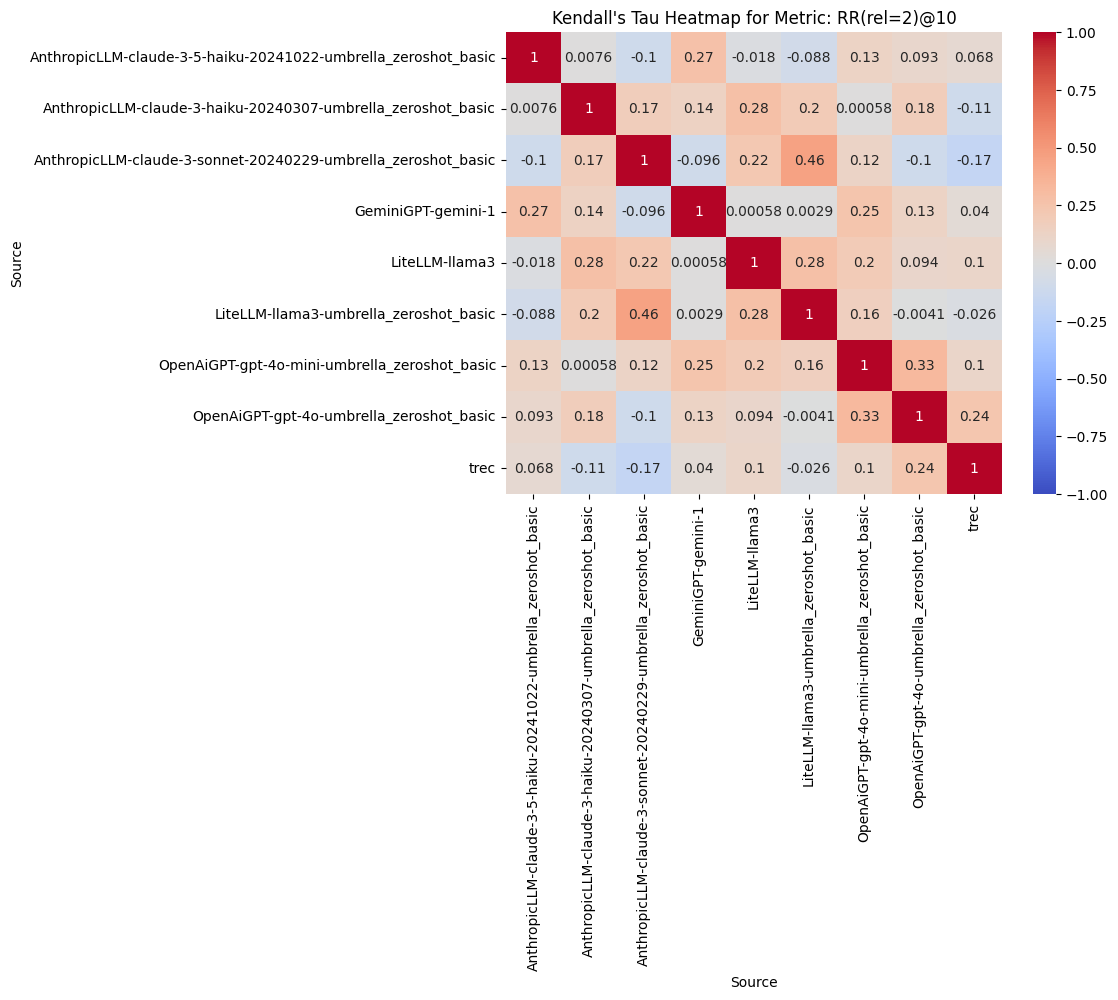

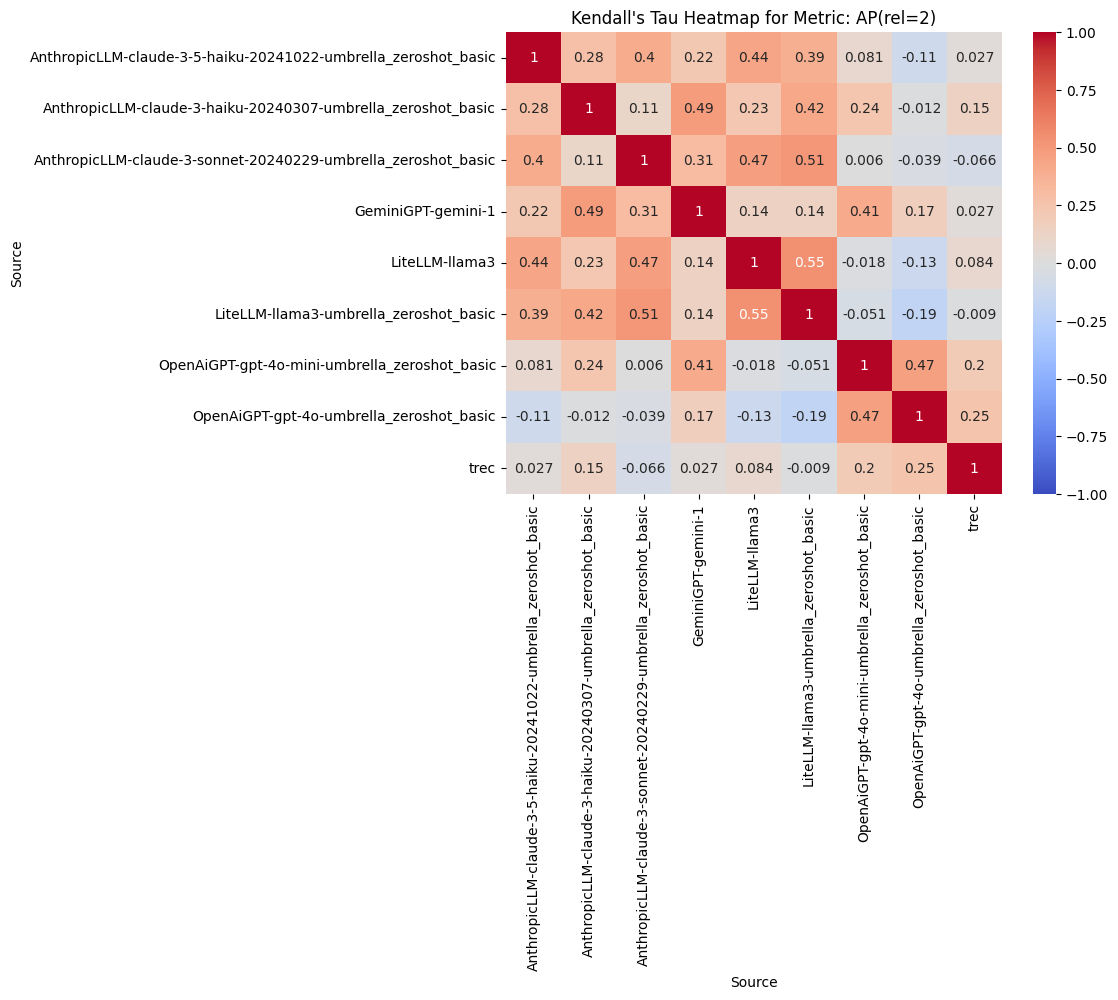

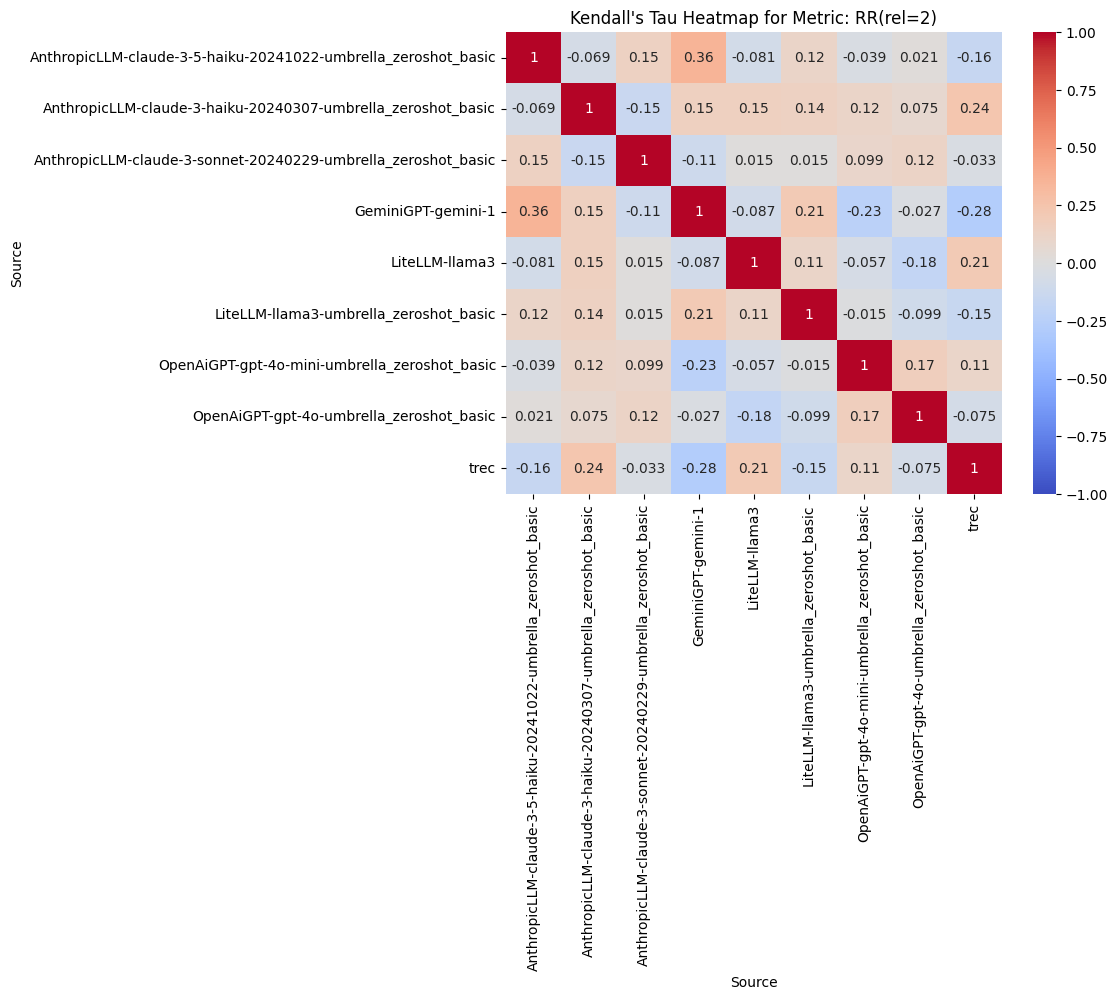

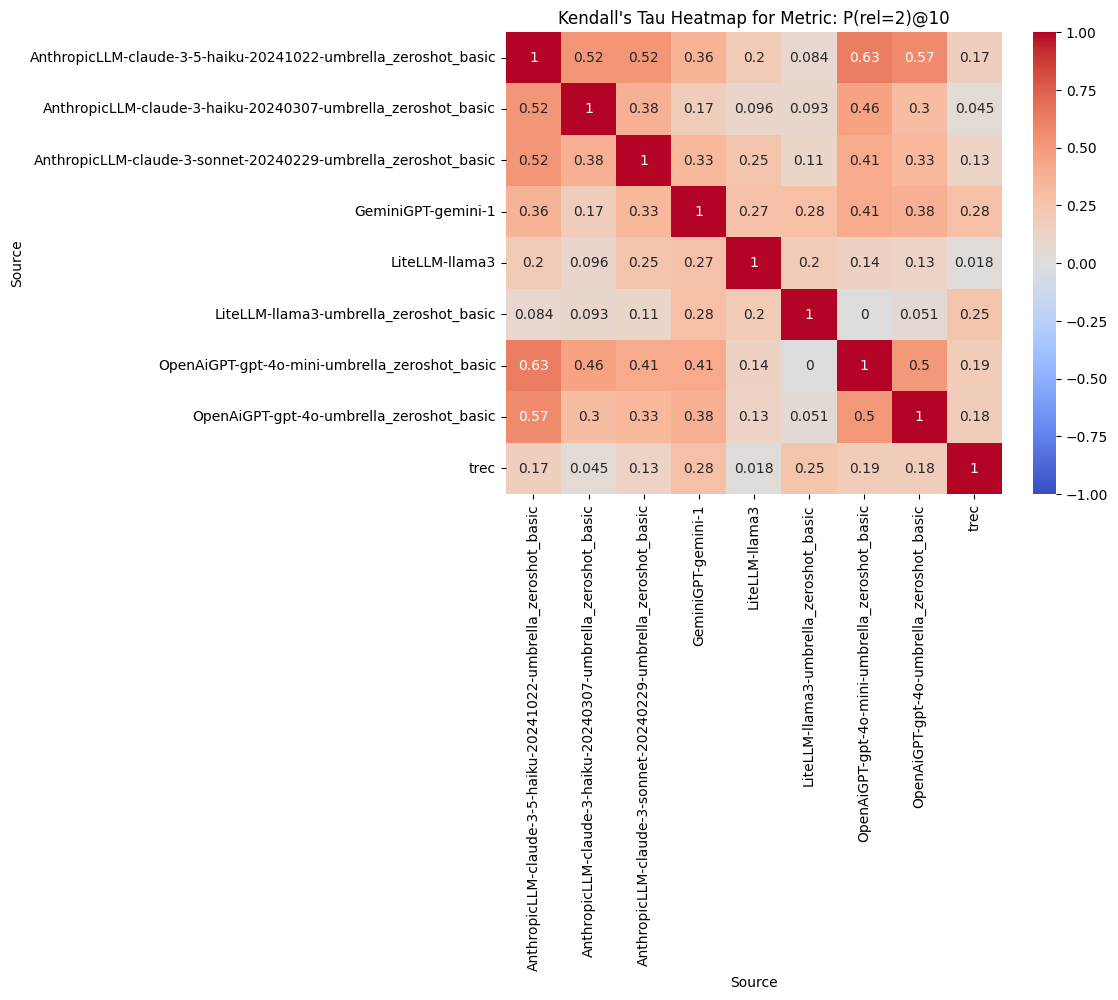

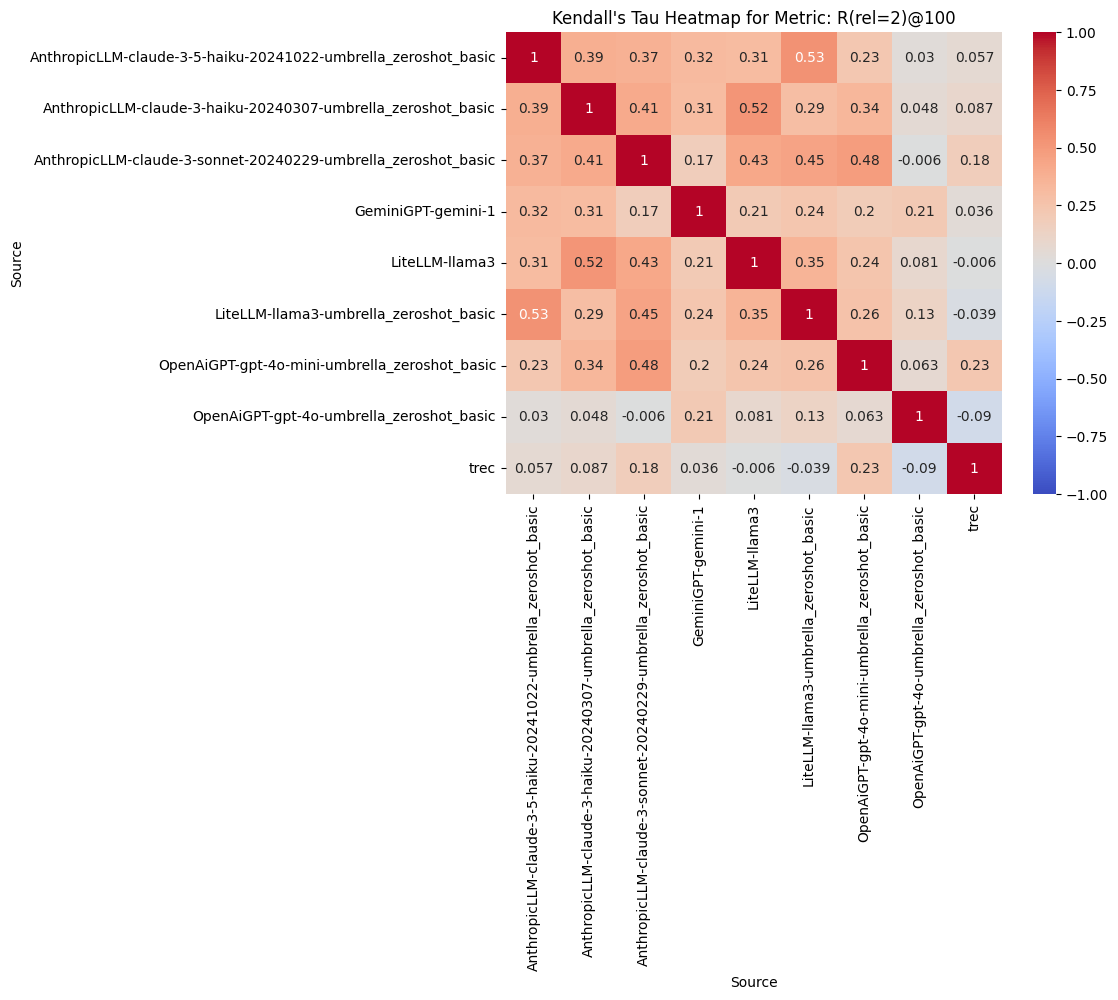

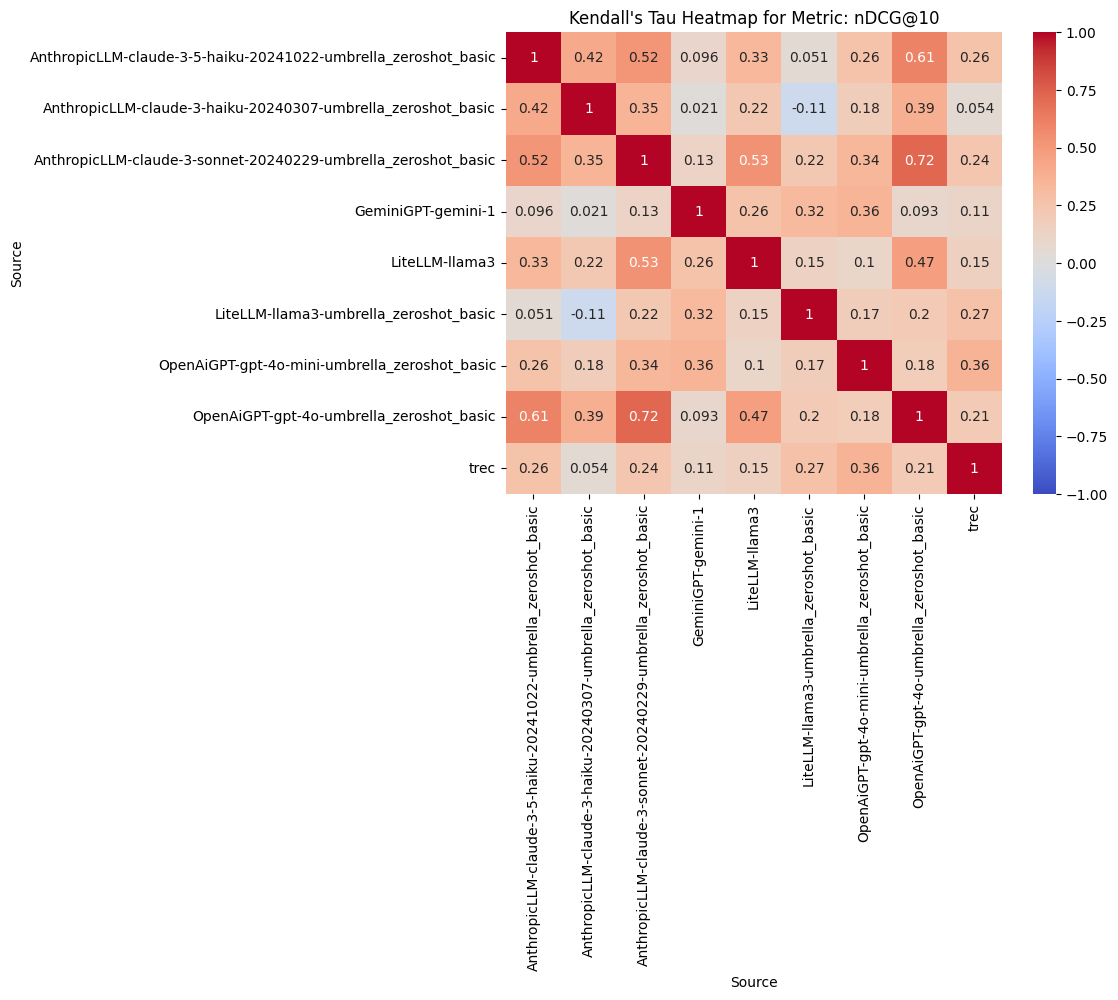

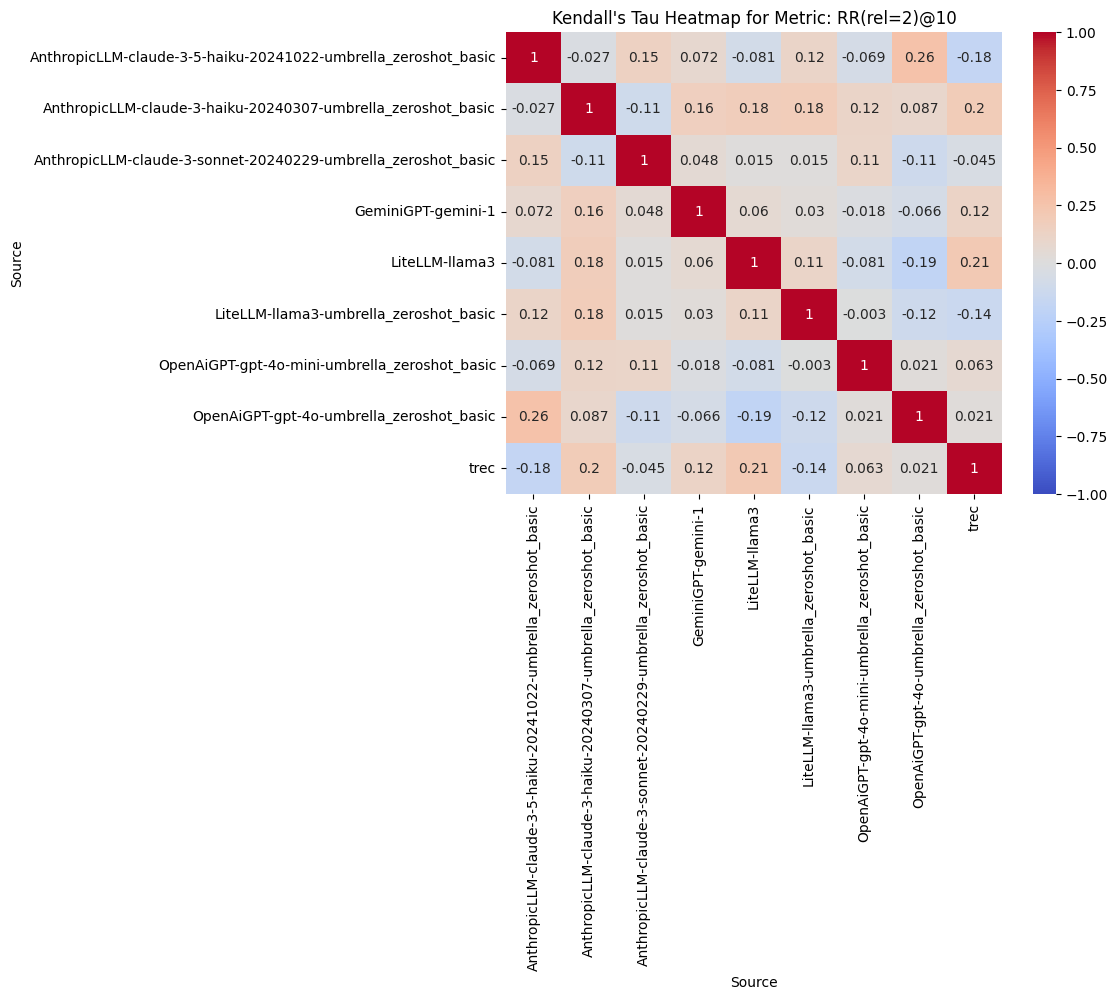

In [65]:
for group, df in eval_result.items():
    calculate_kendalls_tau_heatmap(df)